构造一组输入数据X和其对应的标签y

In [56]:
import numpy as np
import torch

In [57]:
x_values = [i for i in range(11)]
x_train = np.array(x_values,dtype = np.float32)
x_train = x_train.reshape(-1,1)
x_train.shape

(11, 1)

In [58]:
y_values = [3*i+2 for i in range(11)]
y_train = np.array(y_values,dtype = np.float32)
y_train = y_train.reshape(-1,1)
y_train.shape

(11, 1)

In [59]:
import torch.nn as nn

CNN 卷积神经网络

### 线性回归模型
* 其实线性回归就是一个不加激活函数的全连接层

全连接层（Fully Connected Layer，简称FC层），是神经网络中的一种层类型。它是前馈神经网络（Feedforward Neural Network）中的基本组成部分，广泛应用于卷积神经网络（CNNs）和递归神经网络（RNNs）中。

全连接层的特点如下：

1. **全连接性**：在全连接层中，上一层的所有神经元与当前层的每个神经元都连接起来。这意味着每个神经元都会接收到上一层所有神经元的输出。

2. **矩阵运算**：全连接层可以用矩阵运算来表示。假设上一层有 \(n\) 个神经元，当前层有 \(m\) 个神经元，那么这一层的运算可以表示为矩阵乘法：\[ y = Wx + b \]
   - \(x\) 是上一层的输出（一个 \(n \times 1\) 的向量）。
   - \(W\) 是权重矩阵（一个 \(m \times n\) 的矩阵）。
   - \(b\) 是偏置（bias）向量（一个 \(m \times 1\) 的向量）。
   - \(y\) 是当前层的输出（一个 \(m \times 1\) 的向量）。

3. **激活函数**：在全连接层的输出通常会经过激活函数（如ReLU、sigmoid、tanh等）以引入非线性。激活函数作用于每一个神经元的输出，增加网络表达复杂函数的能力。

4. **应用场景**：全连接层通常用于神经网络的最后几层，尤其是在分类问题中，最后一层的全连接层输出分类的概率分布。在卷积神经网络中，通常在卷积层和池化层之后使用全连接层来进行最终的分类。

全连接层的作用是将高维特征映射到目标输出空间，通过优化权重矩阵和偏置向量，使得网络能够学习和泛化复杂的模式和关系。

In [60]:
class LinearRegressionModel(nn.Module):
    def __init__(self,input_dim,output_dim):
        super(LinearRegressionModel,self).__init__()
        self.linear = nn.Linear(input_dim,output_dim)
    
    def forward(self,x):
        out = self.linear(x)
        return out


In [61]:
input_dim = 1

output_dim = 1

model = LinearRegressionModel(input_dim,output_dim)#初始化模型

指定好参数和损失函数

In [62]:
epochs = 1000 #训练轮数
learning_rate = 0.01 #学习率 
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)
criterion = nn.MSELoss()

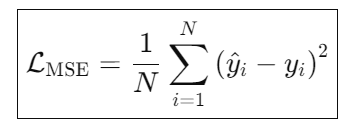

Mean Squar Error

训练函数

In [63]:
10%2

0

In [64]:
#注意转行成tensor
inputs = torch.from_numpy(x_train)
labels = torch.from_numpy(y_train)

for epoch in range(epochs):
    epoch += 1


    #梯度要清零每一次迭代
    optimizer.zero_grad()
   
    #向前传播
    outputs = model(inputs)

    #计算损失
    loss = criterion(outputs, labels)

    #反向传播
    loss.backward()

    #更新权重参数
    optimizer.step()
            
    if epoch % 50 == 0:
        print('epoch {}, loss {}'.format(epoch, loss.item()))
        


epoch 50, loss 0.3400927484035492
epoch 100, loss 0.19397594034671783
epoch 150, loss 0.11063683032989502
epoch 200, loss 0.06310287863016129
epoch 250, loss 0.03599153831601143
epoch 300, loss 0.020528189837932587
epoch 350, loss 0.011708501726388931
epoch 400, loss 0.006678084842860699
epoch 450, loss 0.0038089549634605646
epoch 500, loss 0.0021724840626120567
epoch 550, loss 0.001239113393239677
epoch 600, loss 0.0007067404221743345
epoch 650, loss 0.00040309430914931
epoch 700, loss 0.00022990474826656282
epoch 750, loss 0.00013112780288793147
epoch 800, loss 7.479487976524979e-05
epoch 850, loss 4.26619008067064e-05
epoch 900, loss 2.43345584749477e-05
epoch 950, loss 1.3879329344490543e-05
epoch 1000, loss 7.916311915323604e-06


### 预测模型预测结果

In [66]:
predicted = model(torch.from_numpy(x_train).requires_grad_()).data.numpy()
print(predicted)

[2, 5 , 8 , 11, 14, 17, 20, 23, 26, 29, 32]

[[ 1.994766 ]
 [ 4.9955196]
 [ 7.996274 ]
 [10.997028 ]
 [13.997782 ]
 [16.998535 ]
 [19.99929  ]
 [23.000044 ]
 [26.000797 ]
 [29.00155  ]
 [32.002304 ]]


[2, 5, 8, 11, 14, 17, 20, 23, 26, 29, 32]

In [ ]:
import matplotlib.pyplot as plt

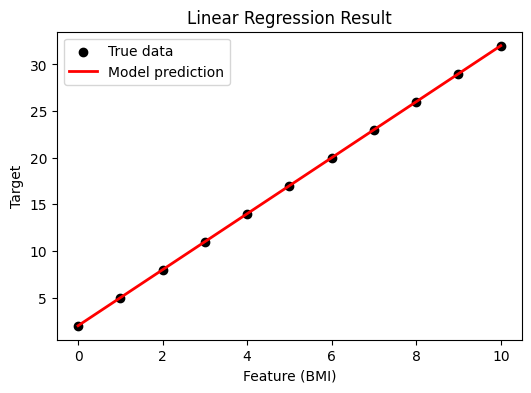

In [ ]:
plt.figure(figsize=(6,4))

# 真实数据
plt.scatter(x_train, y_train, color='black', label='True data')

# 拟合直线
plt.plot(x_train, predicted, color='red', linewidth=2, label='Model prediction')

plt.xlabel("Feature (BMI)")
plt.ylabel("Target")
plt.title("Linear Regression Result")
plt.legend()
plt.show()

### 模型的保存与读取

In [70]:
torch.save(model.state_dict(),'./model/linear/model.pkl')

In [ ]:
model.load_state_dict(torch.load('./model/linear/model.pkl'))

<All keys matched successfully>

### 用GPU进行训练
* 只需要把数据和模型传入到cuda里面就可以了

In [ ]:
# import torch
# import torch.nn as nn
# import numpy as np

# class LinearRegressionModel(nn.Module):
#     def __init__(self,input_dim,output_dim):
#         super(LinearRegressionModel,self).__init__()
#         self.linear = nn.Linear(input_dim,output_dim)
    
#     def forward(self,x):
#         out = self.linear(x)
#         return out
    
# input_dim = 1
# output_dim = 1

# model = LinearRegressionModel(input_dim,output_dim)

# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# model.to(device)

# criterion = nn.MSELoss()

# learning_rate = 0.01

# optimizer = torch.optim.SGD(model.parameters(),lr = learning_rate)

# epochs = 1000

# for epoch in range(epochs):
#     epoch += 1
#     #注意转行成tensor
#     inputs = torch.from_numpy(x_train).to(device)
#     labels = torch.from_numpy(y_train).to(device)

#     #梯度要清零每一次迭代
#     optimizer.zero_grad()
   

#     #向前传播
#     outputs = model(inputs)

#     #计算损失
#     loss = criterion(outputs, labels)

#     #反向传播
#     loss.backward()

#     #更新权重参数
#     optimizer.step()

#     if epoch % 50 == 0:
#         print('epoch {}, loss {}'.format(epoch, loss.item()))


epoch 50, loss 0.979963481426239
epoch 100, loss 0.5589346289634705
epoch 150, loss 0.31879523396492004
epoch 200, loss 0.1818288117647171
epoch 250, loss 0.10370846837759018
epoch 300, loss 0.05915127694606781
epoch 350, loss 0.03373761102557182
epoch 400, loss 0.019242754206061363
epoch 450, loss 0.010975210927426815
epoch 500, loss 0.006259853485971689
epoch 550, loss 0.0035704306792467833
epoch 600, loss 0.0020364553201943636
epoch 650, loss 0.0011615273542702198
epoch 700, loss 0.0006624936941079795
epoch 750, loss 0.00037786512984894216
epoch 800, loss 0.00021551719692070037
epoch 850, loss 0.0001229254703503102
epoch 900, loss 7.011053094174713e-05
epoch 950, loss 3.999084219685756e-05
epoch 1000, loss 2.2807227651355788e-05
